# R · Analog Holidays — Conditional Chain (H1 → H2 → H3 → H4)

Chained variant of P_analog_holidays.ipynb.

Standard 
un_analog_holidays produces an **independent** 24-hour forecast for each target date. Operationally, however, the demand profile of a holiday day is strongly conditioned on what just happened (the eve, the holiday itself, the post-holiday). When forecasting **H2 several hours in advance**, the profile of **H1 is not yet known** — only its forecast — so the natural chain is:

```
H1  ← actual previous day
H2  ← H1 forecast
H3  ← H2 forecast        (H1 is now actual in reality, but H2 still hasn't happened)
H4  ← H3 forecast
```

At each stage the analog candidates are restricted to the *matching* historical day-type so the regressor maps the right preceding profile shape into the right next-day profile shape.

| Stage | Mask (historical days flagged as special) | X looks like |
|---|---|---|
| H1 | historical H1 days | day **before** historical H1 (normal day) |
| H2 | historical H2 days | day **before** historical H2 (= historical H1 / normal) |
| H3 | historical H3 days | day **before** historical H3 (= historical H2) |
| H4 | historical H4 days | day **before** historical H4 (= historical H3) |

All chain logic lives in nalog/analog_holiday_conditional.py.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import analog_holidays.analog.analog_special_days as analog_special_days_module
import analog_holidays.analog.analog_holidays as analog_holidays_module
import analog_holidays.analog.analog_holiday_conditional as analog_conditional_module

analog_special_days_module = importlib.reload(analog_special_days_module)
analog_holidays_module = importlib.reload(analog_holidays_module)
analog_conditional_module = importlib.reload(analog_conditional_module)

from analog_holidays.analog.analog_holiday_conditional import (
    HOLIDAY_STAGES,
    build_chain_summary,
    classify_historical_holidays,
    plot_chain,
    run_analog_holiday_chain,
)

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)

## Parameters

In [2]:
SOURCE_PATH = PROJECT_ROOT / 'analog_holidays' / 'holidays' / 'holiday_demand_mx.csv'

UNIQUE_ID = 'SEN_demand_SIN'

SPECIAL_LABELS = ('holiday',)
SEASON_LENGTH = 24
K = 1000
TYPEDIST = 'pearson'
TYPEREG = 'PCR'
N_COMPONENTS = 3
LEVELS = [80, 95]
MIN_SPECIAL_POINTS = 24
MIN_EVENT_GAP = 24
MAX_EVENTS = None

## Quick sanity check on the historical H1/H2/H3/H4 classification

The chain runner classifies the historical record automatically using the adjacency rule from the `Holiday Expert` agent. We preview the last events to confirm the labels look right before running the chain.

In [3]:
_df_full = analog_holidays_module.load_audit_source(SOURCE_PATH)
_df_region = analog_holidays_module._get_region_df(_df_full, UNIQUE_ID)
_classified = classify_historical_holidays(
    _df_region,
    special_labels=SPECIAL_LABELS,
)
_recent = _classified.loc[_classified['holiday_class'].notna(),
                          ['date', 'label', 'holiday_name', 'holiday_class']]
display(_recent.tail(20))
print({s: int((_classified['holiday_class'] == s).sum()) for s in HOLIDAY_STAGES})

hour_col,date,label,holiday_name,holiday_class
1778,2025-11-16,normal_day,<NA>,H1
1779,2025-11-17,holiday,<NA>,H2
1803,2025-12-11,normal_day,<NA>,H1
1804,2025-12-12,holiday,<NA>,H2
1816,2025-12-24,normal_day,<NA>,H1
1817,2025-12-25,holiday,<NA>,H2
1822,2025-12-30,normal_day,<NA>,H1
1823,2025-12-31,holiday,<NA>,H2
1824,2026-01-01,holiday,<NA>,H3
1825,2026-01-02,normal_day,<NA>,H4


{'H1': 52, 'H2': 53, 'H3': 23, 'H4': 13}


## Define a chain

Each chain is a dict mapping `H1 / H2 / H3 / H4` to target dates. Stages run in order; missing stages are skipped and the next stage uses the most recent available context (forecast or actual day-before profile).

In [4]:
CHAIN_SEMANA_SANTA_2025 = {
    'H1': '2025-04-17',
    'H2': '2025-04-18',
    'H3': '2025-04-19',
    'H4': '2025-04-20',
}

CHAIN_NEW_YEAR_2026 = {
    'H1': '2025-12-31',
    'H2': '2026-01-01',
    'H4': '2026-01-02',
}

CHAIN_CHRISTMAS_2025 = {
    'H1': '2025-12-24',
    'H2': '2025-12-25',
}

CHAINS = {
    'Semana Santa 2025': CHAIN_SEMANA_SANTA_2025,
    'New Year 2026':     CHAIN_NEW_YEAR_2026,
    'Christmas 2025':    CHAIN_CHRISTMAS_2025,
}

## Run the chain(s)

In [5]:
results = {}
for chain_name, chain_dates in CHAINS.items():
    print(f'▶ Running chain: {chain_name}')
    res = run_analog_holiday_chain(
        unique_id=UNIQUE_ID,
        chain_dates=chain_dates,
        source_path=SOURCE_PATH,
        season_length=SEASON_LENGTH,
        k=K,
        typedist=TYPEDIST,
        typereg=TYPEREG,
        n_components=N_COMPONENTS,
        levels=LEVELS,
        special_labels=SPECIAL_LABELS,
        min_special_points=MIN_SPECIAL_POINTS,
        min_event_gap=MIN_EVENT_GAP,
        max_events=MAX_EVENTS,
    )
    results[chain_name] = res
    display(build_chain_summary(res))

▶ Running chain: Semana Santa 2025


,stage,target_date,context_source,n_analogs,extended_series_len,forecast_max,forecast_mean,actual_available,mape_24h_pct,t_sel_s,t_reg_s,fail
0,H1,2025-04-17,actual_2025-04-16,41,37584,41345.946491,37984.701888,True,3.378322,0.000997,0.001994,False
1,H2,2025-04-18,H1_forecast,40,37584,39713.026855,35221.191551,True,6.018658,0.000998,0.000997,False
2,H3,2025-04-19,H2_forecast,19,37584,40765.921680,34786.365593,True,3.704950,0.000997,0.000997,False
3,H4,2025-04-20,H3_forecast,10,37584,44683.174007,38548.341473,True,17.279819,0.000998,0.000994,False


▶ Running chain: New Year 2026


,stage,target_date,context_source,n_analogs,extended_series_len,forecast_max,forecast_mean,actual_available,mape_24h_pct,t_sel_s,t_reg_s,fail
0,H1,2025-12-31,actual_2025-12-30,48,43776,32881.033348,29154.436584,True,3.837036,0.002991,0.001995,False
1,H2,2026-01-01,H1_forecast,47,43776,32446.267757,28036.607098,True,15.047397,0.001995,0.001994,False
2,H4,2026-01-02,H2_forecast,11,43776,34710.551048,30242.406689,True,5.732220,0.001994,0.001995,False


▶ Running chain: Christmas 2025


,stage,target_date,context_source,n_analogs,extended_series_len,forecast_max,forecast_mean,actual_available,mape_24h_pct,t_sel_s,t_reg_s,fail
0,H1,2025-12-24,actual_2025-12-23,46,43608,35123.481982,31770.379161,True,4.926352,0.002006,0.001984,False
1,H2,2025-12-25,H1_forecast,46,43608,34171.163429,30285.113690,True,17.368271,0.001012,0.002028,False


## Visualise the propagation

Each subplot shows one stage of the chain. The dashed grey line is the Y context that fed the stage (real day-before profile for H1, the previous stage's forecast for H2/H3/H4).

── Semana Santa 2025 ──────────────────────────────


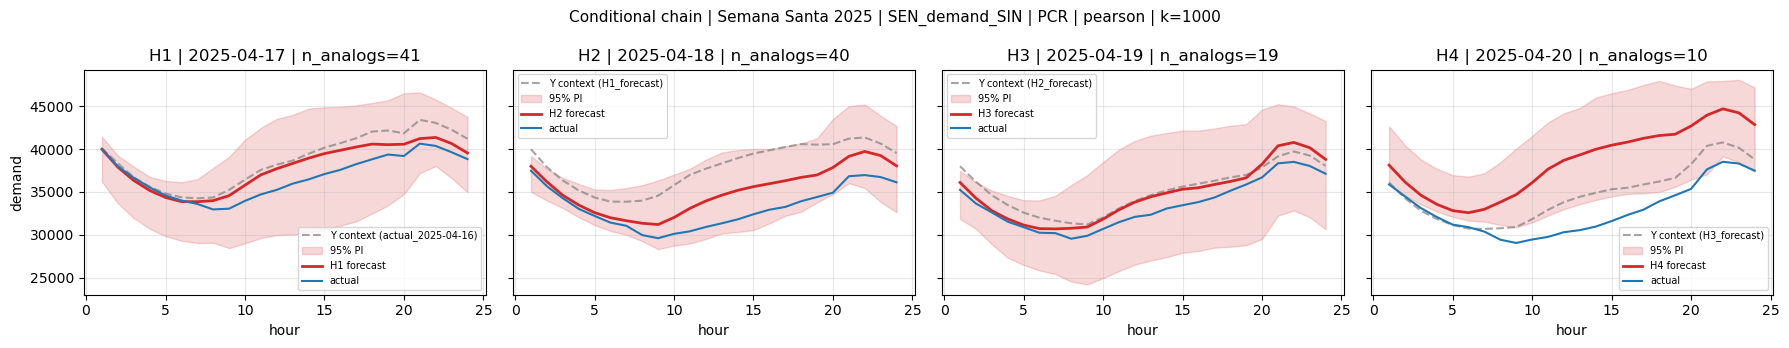

── New Year 2026 ──────────────────────────────


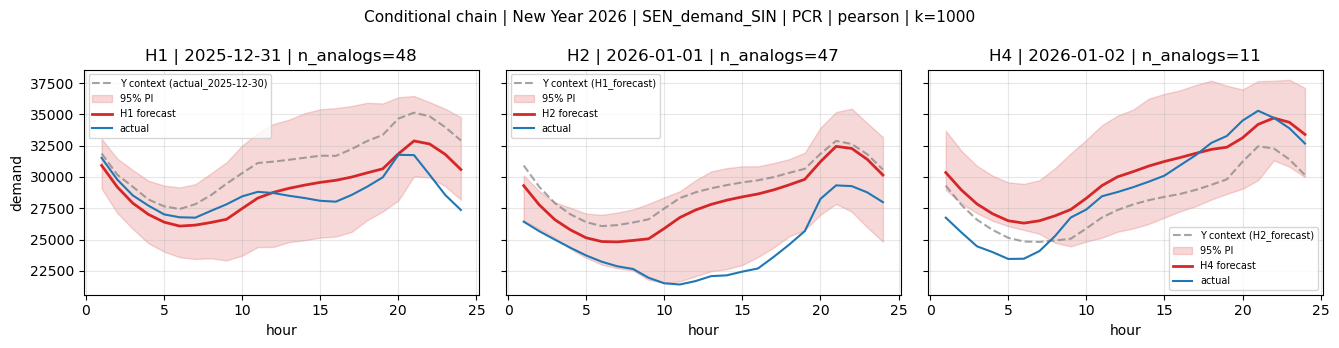

── Christmas 2025 ──────────────────────────────


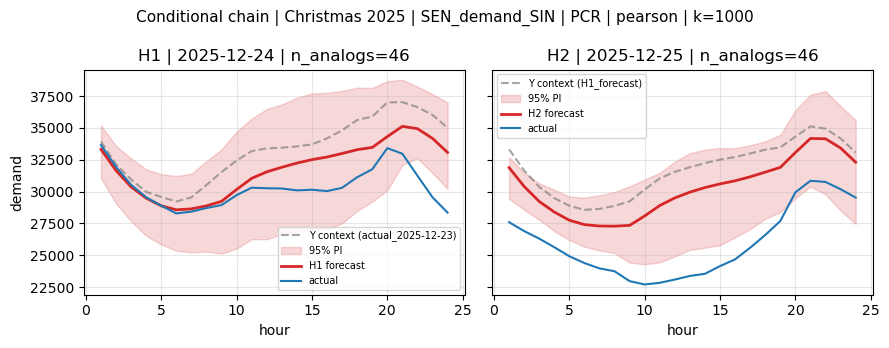

In [6]:
for chain_name, res in results.items():
    print(f'── {chain_name} ──────────────────────────────')
    fig, _ = plot_chain(res)
    fig.suptitle(
        f'Conditional chain | {chain_name} | {UNIQUE_ID} | '
        f'{TYPEREG} | {TYPEDIST} | k={K}',
        fontsize=11,
    )
    plt.show()

## Inspect a single stage

Each stage is a `HolidayStageRun` dataclass with `forecast_profile`, `interval_low/high`, `actual_profile`, `previous_day_profile` (the Y context that was fed in), `positions`, `neighbors2` and `selected_days_df`.

In [7]:
example_chain = next(iter(results.values()))
example_stage = next(iter(example_chain.runs.values()))
print(f'Stage      : {example_stage.stage}')
print(f'Target     : {example_stage.target_date.date()}')
print(f'Context src: {example_stage.context_source}')
print(f'n analogs  : {len(example_stage.positions)}')
print(f'forecast[:5]: {example_stage.forecast_profile[:5]}')
if example_stage.actual_profile is not None:
    print(f'actual[:5]   : {example_stage.actual_profile[:5]}')
display(example_stage.selected_days_df.head())

Stage      : H1
Target     : 2025-04-17
Context src: actual_2025-04-16
n analogs  : 41
forecast[:5]: [39977.53388158 37887.6963816  36336.00273708 35172.73463999
 34350.83837099]
actual[:5]   : [39931.88592 37980.52479 36642.8754  35525.20231 34582.21036]


,context_date,special_date,label,holiday_name,is_declared_holiday,is_outlier,outlier_score,profile_max
0,2020-02-01,2020-02-02,normal_day,<NA>,False,False,NaN,30140.04537
1,2020-03-14,2020-03-15,normal_day,<NA>,False,False,NaN,34000.81027
2,2020-04-07,2020-04-08,normal_day,<NA>,False,False,NaN,35616.28525
3,2020-04-29,2020-04-30,normal_day,<NA>,False,False,NaN,34243.84198
4,2020-09-14,2020-09-15,normal_day,<NA>,False,False,NaN,38066.26599
